In [74]:
import json
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from scikit_posthocs import posthoc_tukey
from statannotations.Annotator import Annotator 

os.chdir('/rds/user/mf774/hpc-work/part_II_project/hovernet/hovernet-conic/inference-results/final-test-inference/')

MODEL = "lizard"
# select from "lizard", "CD3" or "CK"

name_disease_map = {
    'PS23-09764': "normal",
    'PS23-09872': "normal",
    'PS23-10343': "normal",
    'PS23-10347': "normal",
    'PS23-10398': "normal",
    'PS23-10404': "normal",
    'PS23-10411': "normal",
    'PS23-10437': "normal",
    'PS23-10439': "normal",
    'PS23-10441': "normal",
    'PS23-10445': "normal",
    'PS23-10452': "normal",
    'PS23-10137': "normal",
    'PS23-10155': "normal",
    'PS23-12147': "normal",
    'PS23-14038': "coeliac",
    'PS23-14197': "coeliac",
    'PS23-14780': "coeliac",
    'PS23-14976': "coeliac",
    'PS23-15233': "coeliac",
    'PS23-15567': "coeliac",
    'PS23-15579': "coeliac",
    'PS23-16462': "coeliac",
    'PS23-16587': "coeliac",
    'PS23-17229': "coeliac",
    'PS23-17985': "coeliac",
    'PS23-18010': "coeliac",
    'PS23-18011': "coeliac",
    'PS23-19842': "coeliac",
    'PS23-20169': "coeliac",
    'PS23-20460': "NET",
    'PS23-21961': "NET",
    'PS23-14104': "adenocarcinoma",
    'PS23-19454': "adenocarcinoma",
    'PS23-10136': "adenoma",
    'PS23-14152': "adenoma",
    'PS23-14255': "adenoma",
    'PS23-15273': "adenoma",
    'PS23-19293': "adenoma",
    'PS23-18096': "ulcer",
    'PS23-29449': "ulcer",
}

In [75]:
### create density diagnosis csv

INPUT_CSV = f'summary_{MODEL}.csv'
OUTPUT_CSV = f'summary_{MODEL}_density_diagnosis.csv'
PATH_ROOT = '/rds/user/mf774/hpc-work/part_II_project/in-house/inference-data/'

def get_area_from_metadata(directory):
    diagnosis = name_disease_map[directory]
    if diagnosis == "NET" or diagnosis == "adenocarcinoma" or diagnosis == "adenoma" or diagnosis == "ulcer":
        diagnosis = "other"
    directory_path = f'{PATH_ROOT}/{diagnosis}/{directory}/'
    subdirectory_path = os.listdir(directory_path)[0]
    metadata_path = os.path.join(directory_path, subdirectory_path, 'metadata.json')
    with open(metadata_path, "r") as f:
        metadata = json.load(f)
    area = metadata["tissue_area_og_mask"]
    return area

def get_stain_area_density_diagnosis(input_csv, output_csv):
    
    diagnoses = {"diagnosis": []}
    areas = {"area": []}

    # get area and diagnosis
    df = pd.read_csv(input_csv)
    wsis = list(df["wsi"])
    for wsi in wsis:
        diagnoses["diagnosis"].append(name_disease_map[wsi])
        areas["area"].append(get_area_from_metadata(wsi))
    diagnoses = pd.DataFrame(diagnoses)
    areas = pd.DataFrame(areas)
    df['diagnosis'] = diagnoses
    df['area'] = areas

    # calculate nuclei density 
    if MODEL == 'lizard':
        df['total_cell_density'] = (df['total_cells'] / df['area']) * 1000
        df['neutrophil_density'] = (df['neutrophil'] / df['area']) * 1000
        df['epithelial_density'] = (df['epithelial'] / df['area']) * 1000
        df['lymphocyte_density'] = (df['lymphocyte'] / df['area']) * 1000
        df['plasma_density'] = (df['plasma'] / df['area']) * 1000
        df['eosinophil_density'] = (df['eosinophil'] / df['area']) * 1000
        df['connective_density'] = (df['connective'] / df['area']) * 1000
    else:
        df['positive_cell_density'] = (df['positive_cells'] / df['area']) * 1000 
        df['negative_cell_density'] = (df['negative_cells'] / df['area']) * 1000
        df['total_cell_density'] = (df["total_cells"] / df['area']) * 1000
    df.to_csv(output_csv, index=False)
    print(f"Processed data saved to {output_csv}")
    return

# calculate_cell_densities(INPUT_CSV, OUTPUT_CSV)
get_stain_area_density_diagnosis(INPUT_CSV, OUTPUT_CSV)

Processed data saved to summary_lizard_density_diagnosis.csv


/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

adenoma vs. ulcer: Custom statistical test, P_val:4.054e-02
NET vs. adenocarcinoma: Custom statistical test, P_val:2.322e-02
normal vs. adenoma: Custom statistical test, P_val:3.664e-02
adenoma vs. adenocarcinoma: Custom statistical test, P_val:8.491e-04
coeliac vs. adenocarcinoma: Custom statistical test, P_val:2.777e-03


/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

adenoma vs. NET: Custom statistical test, P_val:4.014e-02
ulcer vs. adenocarcinoma: Custom statistical test, P_val:6.651e-04
coeliac vs. NET: Custom statistical test, P_val:1.175e-02
adenoma vs. adenocarcinoma: Custom statistical test, P_val:4.129e-06
normal vs. NET: Custom statistical test, P_val:1.784e-03
coeliac vs. adenocarcinoma: Custom statistical test, P_val:2.369e-07
normal vs. adenocarcinoma: Custom statistical test, P_val:3.329e-08


/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')


...

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

normal vs. coeliac: Custom statistical test, P_val:1.942e-02


/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

normal vs. coeliac: Custom statistical test, P_val:3.408e-02
coeliac vs. adenocarcinoma: Custom statistical test, P_val:1.622e-02


/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

coeliac vs. adenoma: Custom statistical test, P_val:3.796e-03
adenoma vs. adenocarcinoma: Custom statistical test, P_val:2.830e-02


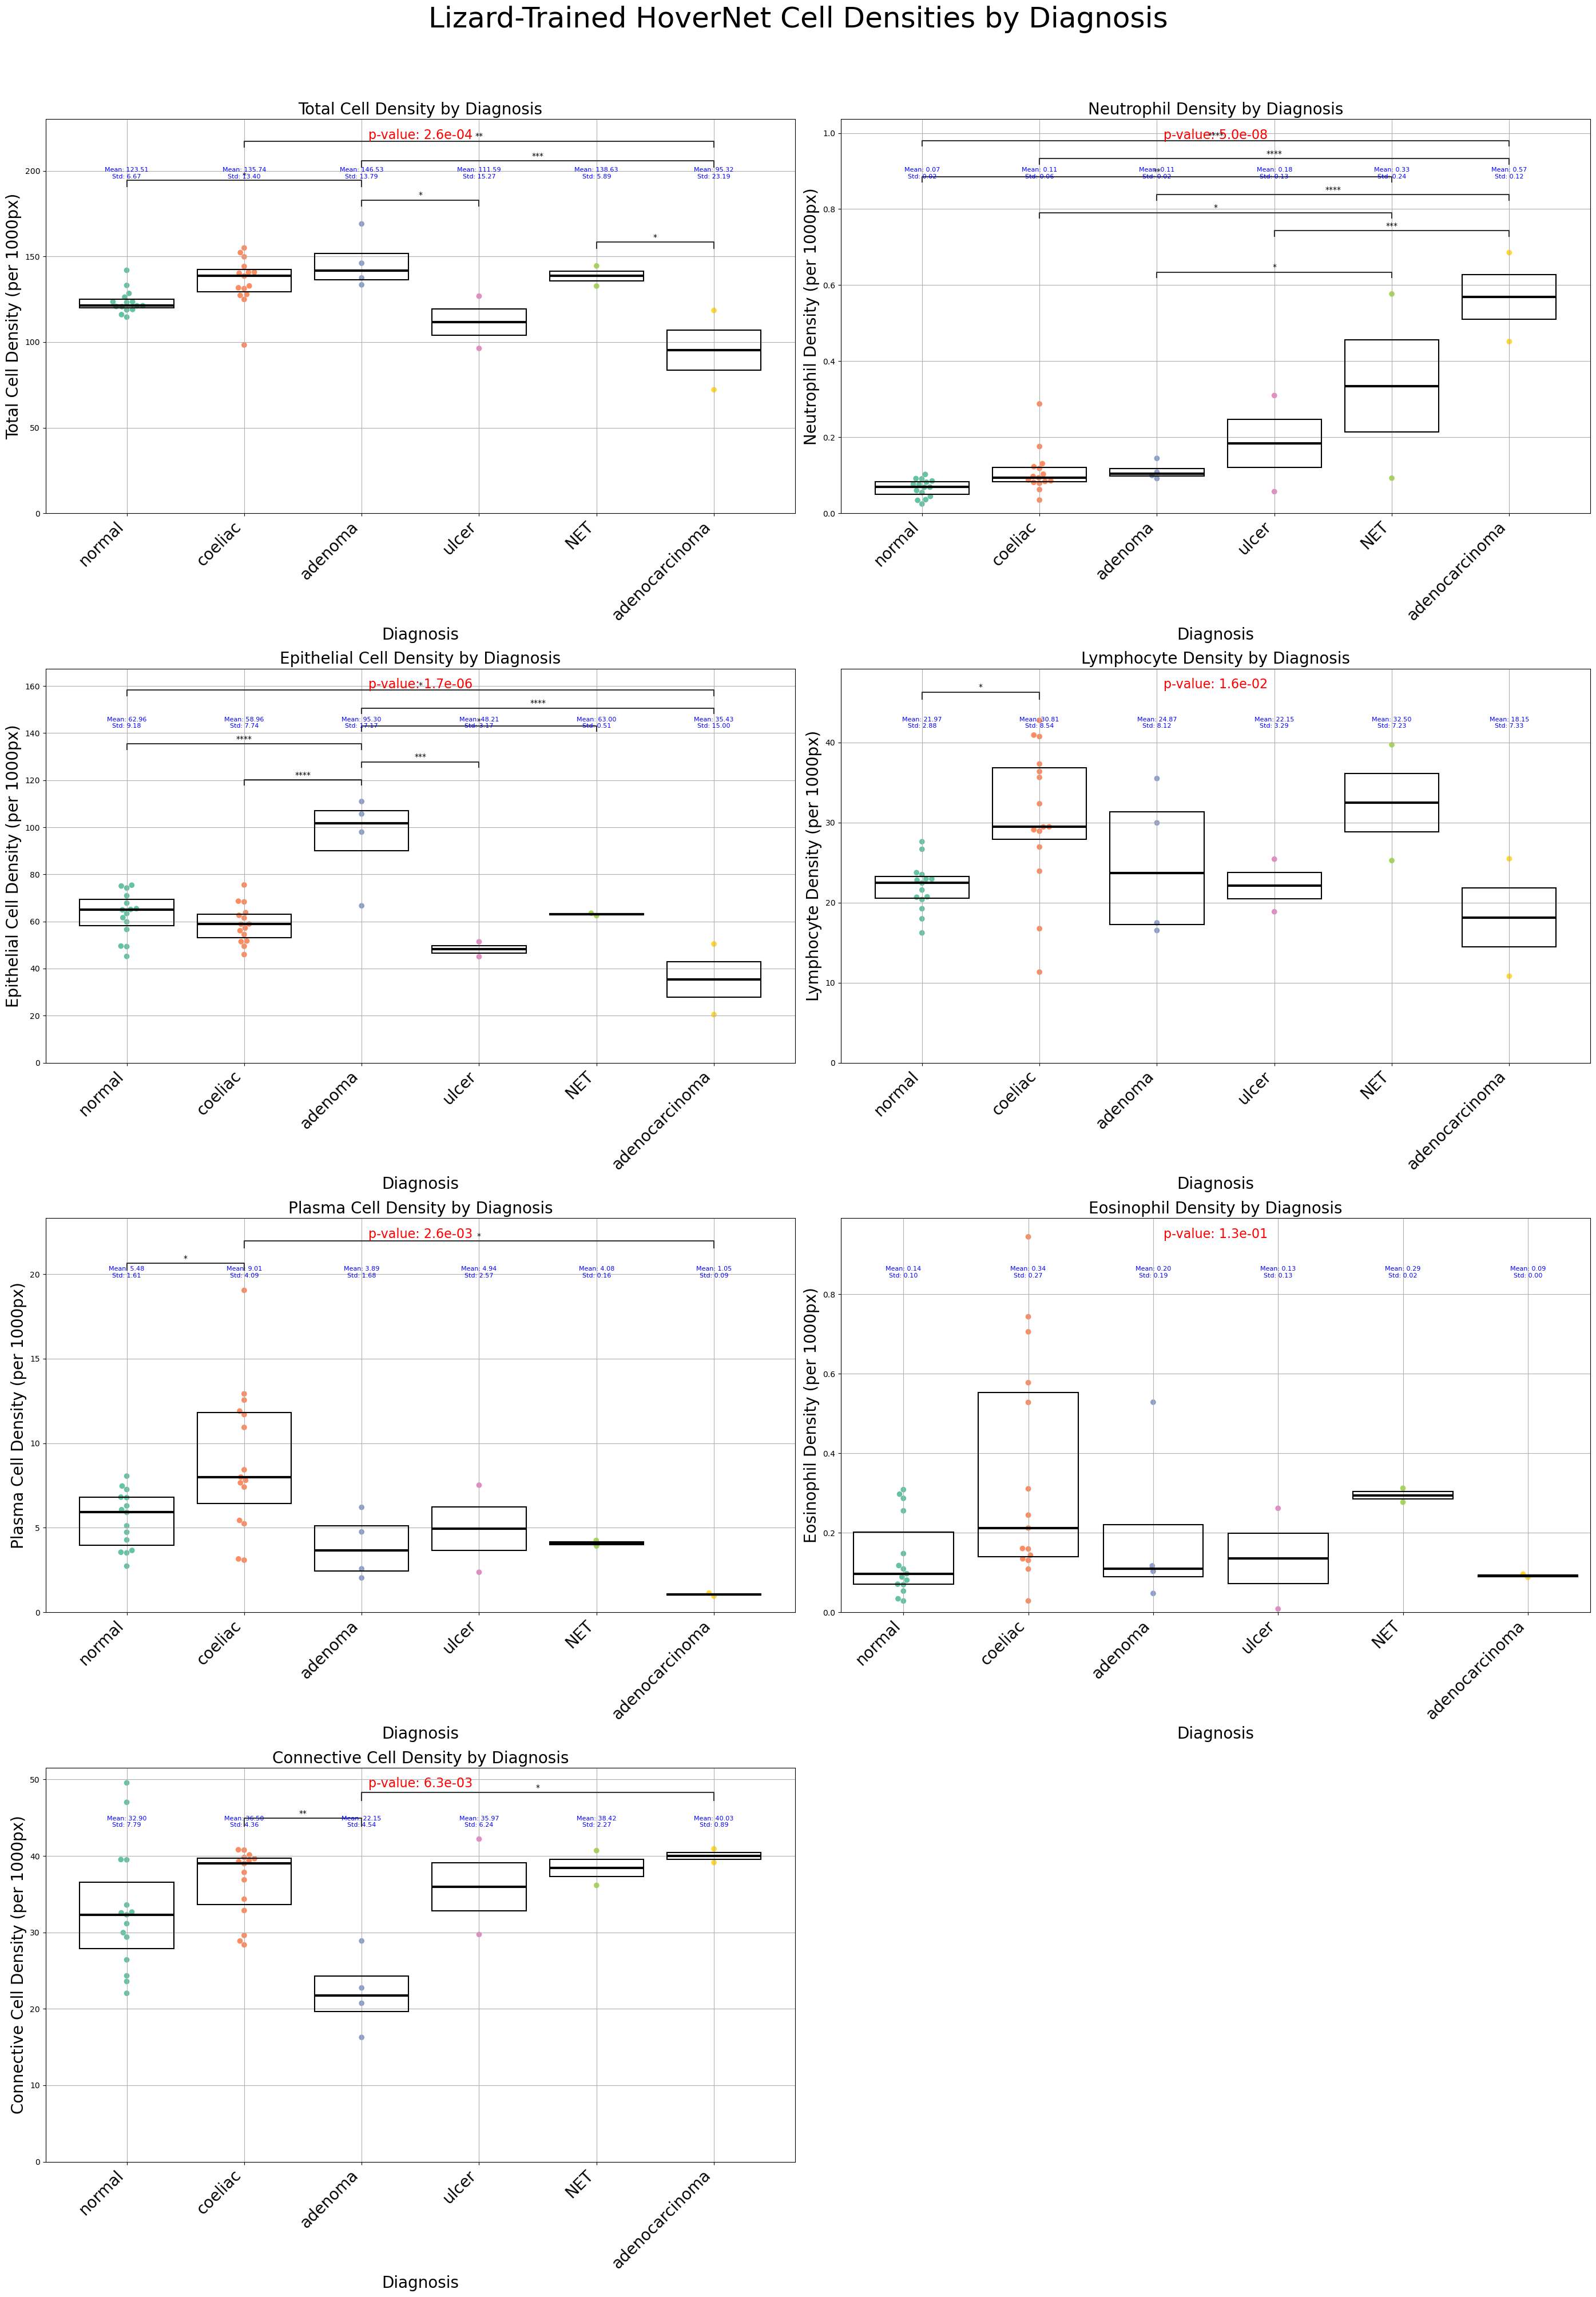

In [76]:
### produce summary scatterplots

file_path = f"summary_{MODEL}_density_diagnosis.csv"
data = pd.read_csv(file_path)

# Define function to generate plots
def plot_data(subset_data, cell_type):
    
    if MODEL == "lizard":
        metrics = ["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density", "plasma_density", "eosinophil_density", "connective_density"]
        metric_names = ["Total Cell Density (per 1000px)", "Neutrophil Density (per 1000px)" , "Epithelial Cell Density (per 1000px)", "Lymphocyte Density (per 1000px)", "Plasma Cell Density (per 1000px)", "Eosinophil Density (per 1000px)", "Connective Cell Density (per 1000px)"]
        plot_titles = ["Total Cell Density by Diagnosis", "Neutrophil Density by Diagnosis", "Epithelial Cell Density by Diagnosis", "Lymphocyte Density by Diagnosis", "Plasma Cell Density by Diagnosis", "Eosinophil Density by Diagnosis", "Connective Cell Density by Diagnosis"]
        fig, axes = plt.subplots(4, 2, figsize=(28, 40))
        plt.suptitle(f'{MODEL.capitalize()}-Trained HoverNet Cell Densities by Diagnosis', fontsize=36, y=1.0025)
    elif MODEL == "CD3":
        metrics = ["total_cell_density", "positive_cell_density", "negative_cell_density"]
        metric_names = ["Total Cell Density (per 1000px)", "T Cell Density (per 1000px) ", "Non T Cell Density (per 1000px)"]
        plot_titles = ["Total Cell Density by Diagnosis", "T Cell Density by Diagnosis", "Non T Cell Density by Diagnosis"]
        fig, axes = plt.subplots(2, 2, figsize=(28, 20))
        plt.suptitle(f'{MODEL}-Trained HoverNet Cell Densities by Diagnosis', fontsize=36, y=1.0025)
    elif MODEL == "CK":
        metrics = ["total_cell_density", "positive_cell_density", "negative_cell_density"]
        metric_names = ["Total Cell Density (per 1000px)", "CK Cell Density (per 1000px) ", "Non CK Cell Density (per 1000px)"]
        plot_titles = ["Total Cell Density by Diagnosis", "CK Cell  Density by Diagnosis", "Non CK Cell Density by Diagnosis"]
        fig, axes = plt.subplots(2, 2, figsize=(28, 20))
        plt.suptitle(f'{MODEL}-Trained HoverNet Cell Densities by Diagnosis', fontsize=36, y=1.0025)
    else:
        print("Invalid model name. Please use 'lizard', 'CD3', or 'CK'.")
        return
    
    groups = subset_data['diagnosis'].unique()
    axes = axes.flatten()

    tukey_results ={}

    for idx, metric in enumerate(metrics):
        sns.swarmplot(ax=axes[idx], x='diagnosis', y=metric, data=subset_data, hue='diagnosis', palette="Set2", size=7, alpha=1, zorder=1)
        sns.boxplot(ax=axes[idx], x='diagnosis', y=metric, data=subset_data, showmeans=False, meanline=False,
                    showfliers=False, whiskerprops={'visible': False}, capprops={'visible': False},
                    medianprops={'color': 'black', 'linewidth': 3, 'zorder': 2},
                    boxprops={'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5, 'zorder': 2})

        axes[idx].set_title(plot_titles[idx], fontsize=20)
        axes[idx].set_xlabel('Diagnosis', fontsize=20)
        axes[idx].set_ylabel(metric_names[idx], fontsize=20)
        axes[idx].grid(True)
        axes[idx].set_ylim(bottom=0)

        for label in axes[idx].get_xticklabels():
            label.set_fontsize(20)
            
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

        # ANOVA test
        group_data = [subset_data[subset_data['diagnosis'] == group][metric] for group in groups]
        f_stat, p_value = f_oneway(*group_data)

        # tukey_hsd test
        
        # code from https://blog.4dcu.be/programming/2021/12/30/Posthoc-Statannotations.html
        tukey_df = posthoc_tukey(subset_data, val_col=metric, group_col="diagnosis")
        remove = np.tril(np.ones(tukey_df.shape), k=0).astype("bool")
        tukey_df[remove] = np.nan
        molten_df = tukey_df.melt(ignore_index=False).reset_index().dropna()
        pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
        p_values = [i[1]["value"] for i in molten_df.iterrows()]
        
        # Annotator for Tukey HSD test, display only significant p-values
        significant_pairs = [(pair, p) for pair, p in zip(pairs, p_values) if p < 0.05]  # Only keep significant pairs
        significant_p_values = [p for p in p_values if p < 0.05]  # Only keep significant p-values
        
        # Ensure valid diagnosis categories in pairs
        valid_pairs = []
        valid_p_values = []

        # Filter out invalid pairs where one or both diagnoses are missing in the data
        for pair, p in significant_pairs:
            if all(diagnosis in subset_data['diagnosis'].values for diagnosis in pair):
                valid_pairs.append(pair)
                valid_p_values.append(p)
        
        if valid_p_values:  # If there are significant p-values, add annotations
            annotator = Annotator(
                axes[idx], valid_pairs, data=subset_data, x="diagnosis", y=metric, zorder=1
            )
            annotator.configure(text_format="star", loc="inside")
            annotator.set_pvalues_and_annotate(valid_p_values)
        
    
        axes[idx].annotate(f'p-value: {p_value:.1e}', xy=(0.5, 0.95), xycoords='axes fraction',
                           ha='center', fontsize=16, color='red')
        
        # Calculate and display mean and std for each group
        for group in groups:
            group_data = subset_data[subset_data['diagnosis'] == group][metric]
            mean = np.mean(group_data)
            std = np.std(group_data)

            # Display mean and std on the plot (at the position of the group on the x-axis)
            x_pos = np.where(groups == group)[0][0]  # Find x position for the group
            axes[idx].text(x_pos, axes[idx].get_ylim()[1] * 0.85,  # Position above the plot
                        f'Mean: {mean:.2f}\nStd: {std:.2f}',
                        ha='center', fontsize=8, color='blue')
        
        tukey_results[metric] = tukey_df

    for j in range(len(metrics), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout(rect=[0,0,1,0.98])
    plt.savefig(f'scatterplot_{cell_type}.png')
    plt.show()
    
    return tukey_results

tukey_df = plot_data(data, MODEL)

In [77]:
### p-values from tukey-hsd

# convert each df with tukey_df dictionary to dataframe
print(f"p-values for model {MODEL}\n")
for metric in tukey_df.keys():
    print(f"Metric: {metric}")
    df = tukey_df[metric]
    print(df.head())


p-values for model lizard

Metric: total_cell_density
         normal   coeliac   adenoma     ulcer       NET  adenocarcinoma
normal      NaN  0.130356  0.036641  0.823937  0.637503        0.067842
coeliac     NaN       NaN  0.681075  0.161325  0.999666        0.002777
adenoma     NaN       NaN       NaN  0.040542  0.980424        0.000849
ulcer       NaN       NaN       NaN       NaN  0.319823        0.807652
NET         NaN       NaN       NaN       NaN       NaN        0.023221
Metric: neutrophil_density
         normal   coeliac   adenoma     ulcer       NET  adenocarcinoma
normal      NaN  0.712321  0.928835  0.434976  0.001784    3.328908e-08
coeliac     NaN       NaN  1.000000  0.841934  0.011747    2.368947e-07
adenoma     NaN       NaN       NaN  0.911996  0.040144    4.129110e-06
ulcer       NaN       NaN       NaN       NaN  0.466062    6.651490e-04
NET         NaN       NaN       NaN       NaN       NaN    7.877557e-02
Metric: epithelial_density
         normal   coeliac   

In [91]:
# setup for all binary classification approaches

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, precision_recall_curve, auc, roc_auc_score, average_precision_score

df = pd.read_csv(f"summary_{MODEL}_density_diagnosis.csv")

# Select features
if MODEL == "lizard":
    features = ["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density", "plasma_density", "eosinophil_density", "connective_density"]
    all_features = df[features]
    total_cell_density = df["total_cell_density"]
    neutrophil_density = df["neutrophil_density"]
    epithelial_density = df["epithelial_density"]
    lymphocyte_density = df["lymphocyte_density"]
    plasma_density = df["plasma_density"]
    eosinophil_density = df["eosinophil_density"]
    connective_density = df["connective_density"]
else:
    features = ["total_cell_density", "positive_cell_density", "negative_cell_density"]
    all_features = df[features]
    total_cell_density = df["total_cell_density"]
    pos_cell_density = df["positive_cell_density"]
    neg_cell_density = df["negative_cell_density"]

target = "diagnosis"
y = df[target].apply(lambda x: 0 if x.lower() == "normal" else 1)
sc = StandardScaler()
all_features = sc.fit_transform(all_features)


Logistic Regression Lizard
Accuracy: 0.7000
Precision: 0.6154
Recall: 0.5333
Negative predictive value: 0.7407
Specificity: 0.8000
Normal F1-score: 0.5714
Pathology F1-score: 0.7692


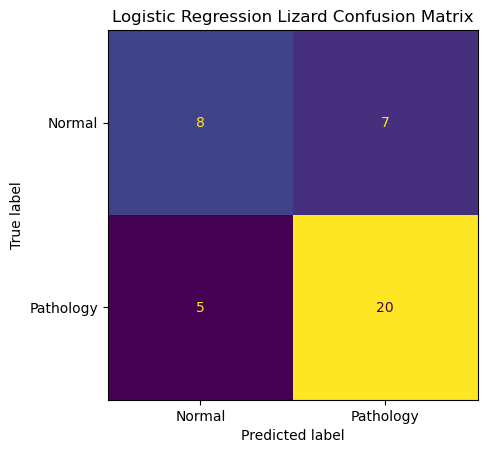


Random Forest Lizard
Accuracy: 0.8250
Precision: 0.7500
Recall: 0.8000
Negative predictive value: 0.8750
Specificity: 0.8400
Normal F1-score: 0.7742
Pathology F1-score: 0.8571


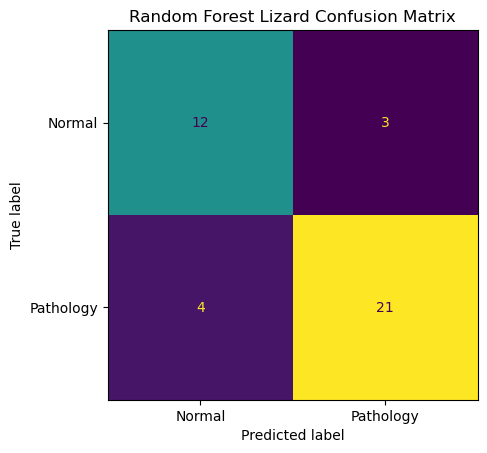


XGBoost Lizard
Accuracy: 0.6750
Precision: 0.5714
Recall: 0.5333
Negative predictive value: 0.7308
Specificity: 0.7600
Normal F1-score: 0.5517
Pathology F1-score: 0.7451


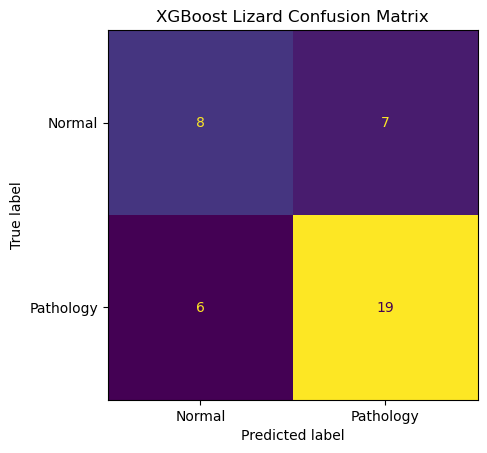


SVM Lizard
Accuracy: 0.7750
Precision: 0.6875
Recall: 0.7333
Negative predictive value: 0.8333
Specificity: 0.8000
Normal F1-score: 0.7097
Pathology F1-score: 0.8163


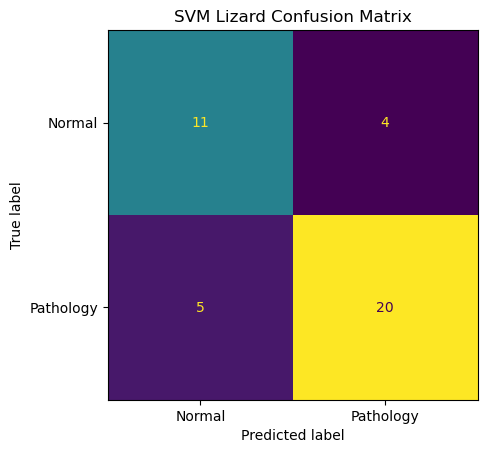

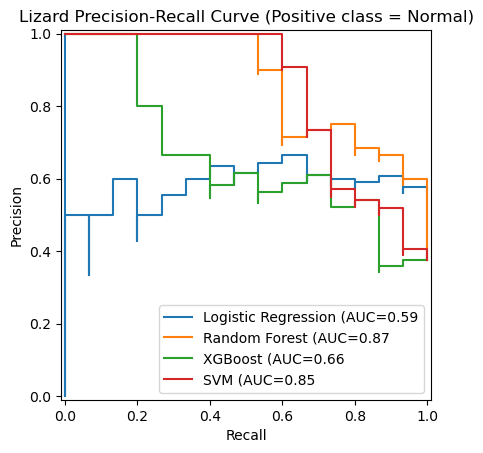

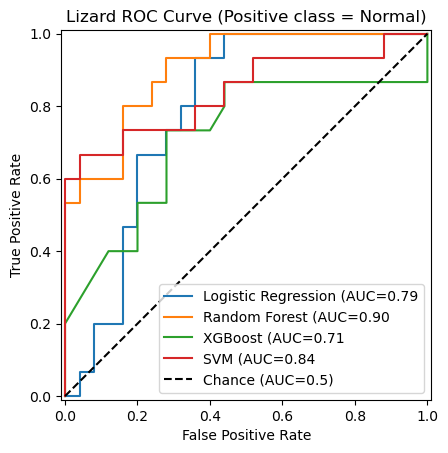

In [ ]:
# get confusion matrix, precision-recall curve, and ROC curve for each model

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    average_precision_score, roc_auc_score
)

# Define models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=10000),
    "XGBoost": GradientBoostingClassifier(n_estimators=500, random_state=42),
    "SVM": SVC(probability=True, kernel="rbf", random_state=42),
}

# Store predictions
results = {}

for name, model in models.items():
    y_pred = cross_val_predict(model, all_features, y, cv=5)
    y_probs = cross_val_predict(model, all_features, y, cv=5, method="predict_proba")[:, 0]  # prob of class 0 (normal)
    acc = accuracy_score(y, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y, y_pred, labels=[0, 1])
    
    print(f"\n{name} {MODEL.capitalize() if MODEL == 'lizard' else MODEL}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision[0]:.4f}")
    print(f"Recall: {recall[0]:.4f}")
    print(f"Negative predictive value: {precision[1]:.4f}") # since precision of netative class is NPV
    print(f"Specificity: {recall[1]:.4f}") # since recall of negative class is specificity
    print(f"Normal F1-score: {f1[0]:.4f}")
    print(f"Pathology F1-score: {f1[1]:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Pathology"])
    disp_cm.plot(colorbar=False)
    plt.title(f"{name} {MODEL.capitalize() if MODEL == 'lizard' else MODEL} Confusion Matrix")
    plt.savefig(f"{name.lower().replace(' ', '_')}_{MODEL}_cm.png", dpi=300)
    plt.show()
    
    # Store results for plotting
    results[name] = {
        "y_probs": y_probs,
        "ap": average_precision_score(y, y_probs, pos_label=0),
        "roc_auc": 1 - roc_auc_score(y, y_probs),  # since positive class is 0
    }

# ----------- Precision-Recall Curve -----------
fig, ax = plt.subplots()
for name, res in results.items():
    PrecisionRecallDisplay.from_predictions(
        y, res["y_probs"], pos_label=0,
        label=f"{name} (AUC={res['ap']:.2f})",
        ax=ax
    )
ax.set_title(f"{MODEL.capitalize() if MODEL == 'lizard' else MODEL} Precision-Recall Curve (Positive class = Normal)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower right")
plt.savefig(f"{MODEL}_combined_precision_recall.png", dpi=300)
plt.show()

# ----------- ROC Curve -----------
fig, ax = plt.subplots()
for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y, res["y_probs"], pos_label=0,
        label=f"{name} (AUC={res['roc_auc']:.2f})",
        ax=ax
    )
ax.plot([0, 1], [0, 1], 'k--', label="Chance (AUC=0.5)")
ax.set_title(f"{MODEL.capitalize() if MODEL == 'lizard' else MODEL} ROC Curve (Positive class = Normal)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.savefig(f"{MODEL}_combined_roc.png", dpi=300)
plt.show()


In [157]:
### 5-fold cross validation random forest single feature

# Assume your features are pandas Series
features = {
    'all_features': all_features,
    'total_cell_density': total_cell_density,
    'neutrophil_density': neutrophil_density,
    'epithelial_density': epithelial_density,
    'lymphocyte_density': lymphocyte_density,
    'plasma_density': plasma_density,
    'eosinophil_density': eosinophil_density,
    'connective_density': connective_density
}

sc = StandardScaler()

# Standardize all features
for key in features:
    if features[key].ndim == 1:
        features[key] = sc.fit_transform(features[key].values.reshape(-1, 1))
    else:
        features[key] = sc.fit_transform(features[key])

results = []
for feature_name, feature_data in features.items():
    print(f"\n=== Random Forest Using '{feature_name}' ===")

    rand_forest = RandomForestClassifier(random_state=42, n_estimators=10000)
    y_pred = cross_val_predict(rand_forest, feature_data, y, cv=5)

    accuracy = accuracy_score(y, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y, y_pred, labels=[0, 1])

    metrics = {
        'accuracy': accuracy,
        'precision': precision[0],
        'recall': recall[0],
        'NPV': precision[1], # negative predictive value is the same as precision for the negative class
        'specificity': recall[1], # specificity is the same as recall for the negative class
        'normal F1 score': f1[0],
        'pathology F1 score': f1[1],
    }

    for metric_name, value in metrics.items():
        results.append({
            'feature': feature_name,
            'metric': metric_name,
            'value': value
        })

    print(f"Overall Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision[0]:.4f}")
    print(f"Recall: {recall[0]:.4f}")
    print(f"Negative Predictive Value: {precision[1]:.4f}")
    print(f"Specificity: {recall[1]:.4f}")
    print(f"Normal F1 Score: {f1[0]:.4f}")
    print(f"Pathology F1 Score: {f1[1]:.4f}")

df_results = pd.DataFrame(results)


=== Random Forest Using 'all_features' ===
Overall Accuracy: 0.8250
Precision: 0.7500
Recall: 0.8000
Negative Predictive Value: 0.8750
Specificity: 0.8400
Normal F1 Score: 0.7742
Pathology F1 Score: 0.8571

=== Random Forest Using 'total_cell_density' ===
Overall Accuracy: 0.8250
Precision: 0.7857
Recall: 0.7333
Negative Predictive Value: 0.8462
Specificity: 0.8800
Normal F1 Score: 0.7586
Pathology F1 Score: 0.8627

=== Random Forest Using 'neutrophil_density' ===
Overall Accuracy: 0.6750
Precision: 0.5625
Recall: 0.6000
Negative Predictive Value: 0.7500
Specificity: 0.7200
Normal F1 Score: 0.5806
Pathology F1 Score: 0.7347

=== Random Forest Using 'epithelial_density' ===
Overall Accuracy: 0.4750
Precision: 0.2857
Recall: 0.2667
Negative Predictive Value: 0.5769
Specificity: 0.6000
Normal F1 Score: 0.2759
Pathology F1 Score: 0.5882

=== Random Forest Using 'lymphocyte_density' ===
Overall Accuracy: 0.8000
Precision: 0.7333
Recall: 0.7333
Negative Predictive Value: 0.8400
Specificity:

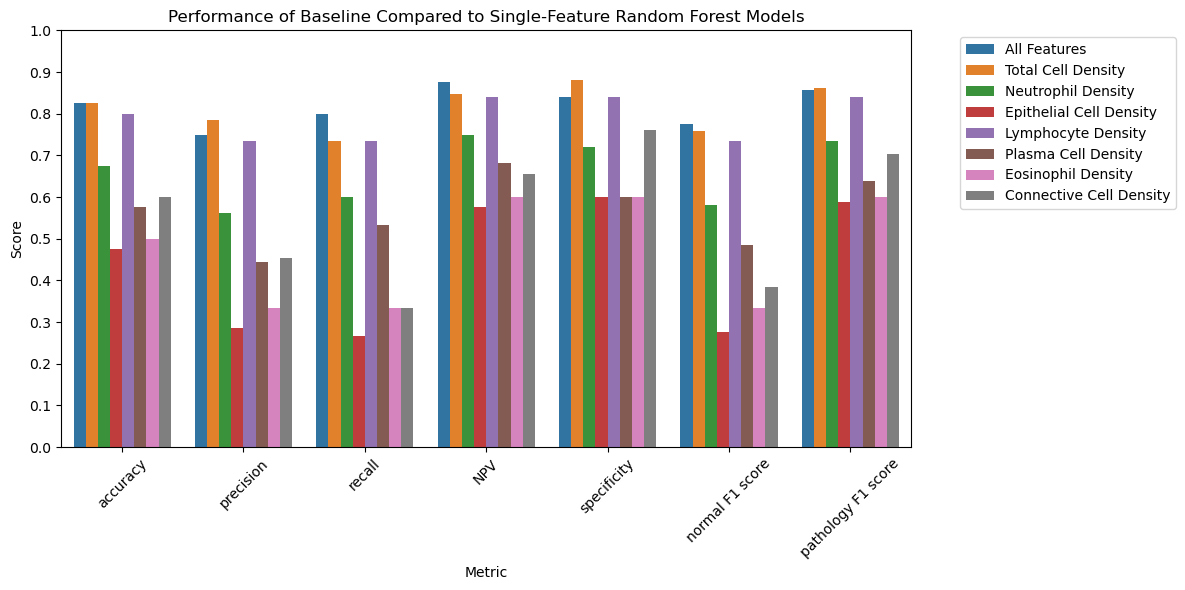

In [ ]:
# plot barchart of feature importance

plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x="metric", y="value", hue="feature")
plt.title("Performance of Baseline Compared to Single-Feature Random Forest Models")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1.00)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=45)
handles, labels = plt.gca().get_legend_handles_labels()
labels = ["All Features", "Total Cell Density", "Neutrophil Density", "Epithelial Cell Density", "Lymphocyte Density", "Plasma Cell Density", "Eosinophil Density", "Connective Cell Density"]
plt.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"single_feature_random_forest.png", dpi=300)
plt.show()